# 0 | Benchmark

This notebook will outline a process for benchmarking the import speed as we implement each of the 3 ideas for improving memory size partitioning:
1. fixed length columns: use known size instead of computing per row
2. vectorized methods: to get size/length of dynamic length columns (if such methods exist)
3. size calcs per histogram pixel: instead of per row

The structure of the notebook is as follows:
- First, we will establish a baseline against which to test.
- Then, we will break out into 3 sections, and run a new benchmarking trial (on the corresponding branch), and record timings.
- Compare results.

In [1]:
import os
import time
import socket
from pathlib import Path

import lsdb
import matplotlib.patches as mpatches
from dask.distributed import Client
from hats_import.pipeline import pipeline_with_client
from hats_import.catalog.arguments import ImportArguments

In [2]:
output_dir = Path("/sdf/data/rubin/user/olynn/mem_size_benchmarks")

## 0.Baseline

*Run the first trial using lsdb main; record the time taken to re-import each of 4 cone searchs.*

### Create trial catalogs

**Catalog:** ZTF DR22
  - Has lightcurves, is 7.2 TiB (and is public, which is a nice bonus)

**Cone search regions:** (thanks Kostya!)  
- ra=170, dec=-25
- ra=255, dec=40

**Dask parameters:**  
- n workers: 32
- threads per worker: 2
- mem per worker: 14GB

In [3]:
# Make a dask client; set up dashboard for slacd

client = Client(
    n_workers=16,
    threads_per_worker=2,
    memory_limit="28GB",
)

username = os.getenv("USER")
current_compute_node = socket.gethostname()
dashboard_port = client.scheduler_info()['services']['dashboard']

print(f"Run this in a local shell:")
print(f"  ssh -L 8787:{current_compute_node}:{dashboard_port} -J {username}@s3dflogin.slac.stanford.edu {username}@{current_compute_node}")
print(f"\nThen open: http://localhost:8787/status")

Run this in a local shell:
  ssh -L 8787:sdfiana012:8787 -J olynn@s3dflogin.slac.stanford.edu olynn@sdfiana012

Then open: http://localhost:8787/status


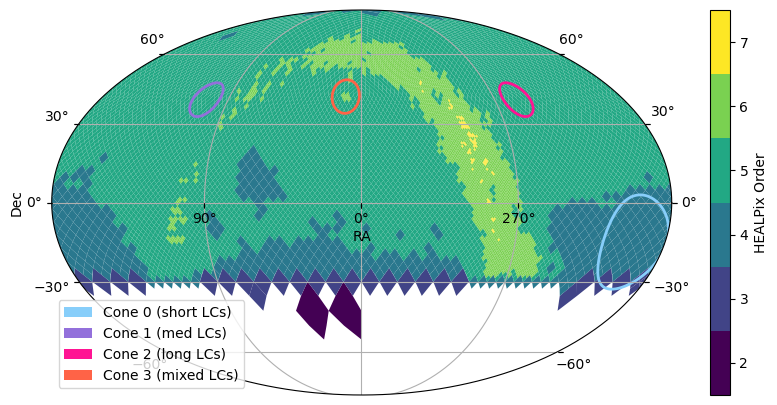

In [13]:
# Load ZTF DR22 and define cone search regions
 
ztf = lsdb.open_catalog("https://data.lsdb.io/hats/ztf_dr22")

fig, ax = ztf.plot_pixels(plot_title="ZTF DR22")

handles = []
colors = ["lightskyblue", "mediumpurple", "deeppink", "tomato"]
labels = ["Cone 0 (short LCs)", "Cone 1 (med LCs)", "Cone 2 (long LCs)", "Cone 3 (mixed LCs)"]
cones = [
    lsdb.ConeSearch(ra=-160, dec=-15, radius_arcsec=18 * 3600),  # short LCs
    lsdb.ConeSearch(ra=-255, dec= 40, radius_arcsec=7 * 3600),  # medium LCs
    lsdb.ConeSearch(ra=255, dec=40, radius_arcsec=7 * 3600),    # long LCs
    lsdb.ConeSearch(ra=10.7, dec=41.3, radius_arcsec=7 * 3600)  # mixed LCs (M31)
]

for i, cone in enumerate(cones):
    cone.plot(ec=colors[i], fc="#00000000", linewidth=2, ax=ax, fig=fig)
    handles.append(mpatches.Patch(fc=colors[i], linewidth=2, label=labels[i]),)

ax.legend(loc="lower left", handles=handles)

In [14]:
# Generate benchmark catalogs

for i, cone in enumerate(cones):
    print(f"Generating trial catalog {i}...")
    ztf.search(cone).write_catalog(
        base_catalog_path=output_dir,
        catalog_name=f"trial_{i}",
        overwrite=True
    )

Generating trial catalog 0...



Generating trial catalog 1...

Generating trial catalog 2...

Generating trial catalog 3...



In [ ]:
# Remove unneccessary margins; check general catalog sizes

# How to use write catalog without writing a collection? :')
# !rm -r {output_dir}/*arcs
# !rm {output_dir}/collection.properties

!echo "Overall catalog sizes:"
!du -h --max-depth=1 {output_dir} | sort -rh

!echo "Top 5 files in short-LC catalog:"
!find {output_dir}/trial_0/dataset/ -type f | xargs du -h | sort -rh | head -n 5

Overall catalog sizes:


97G	/sdf/data/rubin/user/olynn/mem_size_benchmarks
34G	/sdf/data/rubin/user/olynn/mem_size_benchmarks/trial_2
26G	/sdf/data/rubin/user/olynn/mem_size_benchmarks/trial_3
21G	/sdf/data/rubin/user/olynn/mem_size_benchmarks/trial_1
17G	/sdf/data/rubin/user/olynn/mem_size_benchmarks/trial_0
0	/sdf/data/rubin/user/olynn/mem_size_benchmarks/baseline
Top 5 files in short-LC catalog:
349M	/sdf/data/rubin/user/olynn/mem_size_benchmarks/trial_0/dataset/Norder=4/Dir=0/Npix=1616.parquet
338M	/sdf/data/rubin/user/olynn/mem_size_benchmarks/trial_0/dataset/Norder=4/Dir=0/Npix=1618.parquet
333M	/sdf/data/rubin/user/olynn/mem_size_benchmarks/trial_0/dataset/Norder=4/Dir=0/Npix=2799.parquet
323M	/sdf/data/rubin/user/olynn/mem_size_benchmarks/trial_0/dataset/Norder=4/Dir=0/Npix=2790.parquet
313M	/sdf/data/rubin/user/olynn/mem_size_benchmarks/trial_0/dataset/Norder=4/Dir=0/Npix=2793.parquet


### Run trials

In [16]:
!mkdir {output_dir}/baseline

In [26]:
trial_times = []

for i in range(4):
    print(f"Starting trial {i}...")
    start = time.perf_counter()
    args = ImportArguments.reimport_from_hats(
        f"{output_dir}/trial_{i}",
        f"{output_dir}/baseline",
        output_artifact_name=f"baseline_{i}",
        byte_pixel_threshold=1_000_000_000,  # 1GB
        progress_bar=False
    )
    pipeline_with_client(args, client)
    elapsed = time.perf_counter() - start
    
    print(f"Trial {i} completed in {elapsed} seconds.")
    trial_times.append(elapsed)

Starting trial 0...
Trial 0 completed in 535.8822271861136 seconds.
Starting trial 1...
Trial 1 completed in 647.7431479096413 seconds.
Starting trial 2...
Trial 2 completed in 1029.1792556233704 seconds.
Starting trial 3...
Trial 3 completed in 782.6224995218217 seconds.


In [28]:
for i, seconds in enumerate(trial_times):
    m, s = divmod(seconds, 60)
    print(f"Trial {i} ran in {int(m):2d}m {s:4.1f}s")

Trial 0 ran in  8m 55.9s
Trial 1 ran in 10m 47.7s
Trial 2 ran in 17m  9.2s
Trial 3 ran in 13m  2.6s
